In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("train.csv")

df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [2]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (421570, 5)

Columns:
Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday'], dtype='object')

Data Types:
Store             int64
Dept              int64
Date             object
Weekly_Sales    float64
IsHoliday          bool
dtype: object

Missing Values:
Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64


In [3]:
# Convert Date column from object to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Sort data by date
df = df.sort_values("Date").reset_index(drop=True)

# Check the result
print(df.dtypes)
print("\nDate range:")
print("From:", df["Date"].min())
print("To:", df["Date"].max())

df.head()

Store                    int64
Dept                     int64
Date            datetime64[ns]
Weekly_Sales           float64
IsHoliday                 bool
dtype: object

Date range:
From: 2010-02-05 00:00:00
To: 2012-10-26 00:00:00


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,29,5,2010-02-05,15552.08,False
2,29,6,2010-02-05,3200.22,False
3,29,7,2010-02-05,10820.05,False
4,29,8,2010-02-05,20055.64,False


In [4]:
# Create time-based features
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Week"] = df["Date"].dt.isocalendar().week.astype(int)
df["Day"] = df["Date"].dt.day

df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Year,Month,Week,Day
0,1,1,2010-02-05,24924.50,False,2010,2,5,5
1,29,5,2010-02-05,15552.08,False,2010,2,5,5
2,29,6,2010-02-05,3200.22,False,2010,2,5,5
3,29,7,2010-02-05,10820.05,False,2010,2,5,5
4,29,8,2010-02-05,20055.64,False,2010,2,5,5


In [5]:
weekly_sales = df.groupby("Date")["Weekly_Sales"].sum().reset_index()

weekly_sales.head()

,Date,Weekly_Sales
0,2010-02-05,49750740.50
1,2010-02-12,48336677.63
2,2010-02-19,48276993.78
3,2010-02-26,43968571.13
4,2010-03-05,46871470.30


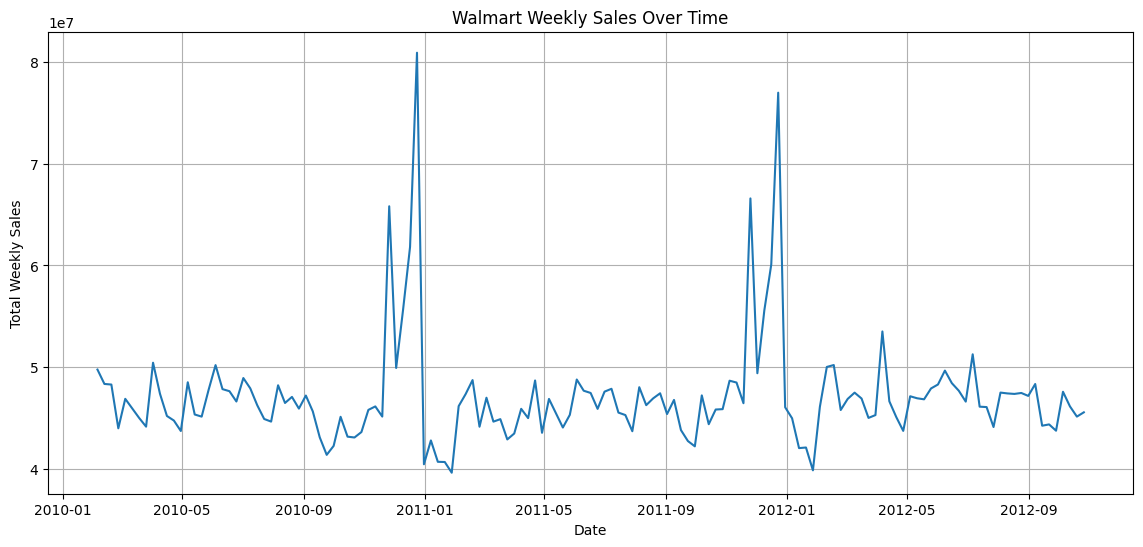

In [6]:
plt.figure(figsize=(14, 6))

plt.plot(
    weekly_sales["Date"],
    weekly_sales["Weekly_Sales"]
)

plt.title("Walmart Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Weekly Sales")
plt.grid(True)

plt.show()

In [7]:
# Create lag features
weekly_sales["Lag_1"] = weekly_sales["Weekly_Sales"].shift(1)
weekly_sales["Lag_2"] = weekly_sales["Weekly_Sales"].shift(2)
weekly_sales["Lag_4"] = weekly_sales["Weekly_Sales"].shift(4)

weekly_sales.head(10)

,Date,Weekly_Sales,Lag_1,Lag_2,Lag_4
0,2010-02-05,49750740.50,NaN,NaN,NaN
1,2010-02-12,48336677.63,49750740.50,NaN,NaN
2,2010-02-19,48276993.78,48336677.63,49750740.50,NaN
3,2010-02-26,43968571.13,48276993.78,48336677.63,NaN
4,2010-03-05,46871470.30,43968571.13,48276993.78,49750740.50
5,2010-03-12,45925396.51,46871470.30,43968571.13,48336677.63
6,2010-03-19,44988974.64,45925396.51,46871470.30,48276993.78
7,2010-03-26,44133961.05,44988974.64,45925396.51,43968571.13
8,2010-04-02,50423831.26,44133961.05,44988974.64,46871470.30
9,2010-04-09,47365290.44,50423831.26,44133961.05,45925396.51


In [8]:
weekly_sales["Rolling_Mean_4"] = (
    weekly_sales["Weekly_Sales"]
    .shift(1)
    .rolling(window=4)
    .mean()
)

weekly_sales.head(10)

,Date,Weekly_Sales,Lag_1,Lag_2,Lag_4,Rolling_Mean_4
0,2010-02-05,49750740.50,NaN,NaN,NaN,NaN
1,2010-02-12,48336677.63,49750740.50,NaN,NaN,NaN
2,2010-02-19,48276993.78,48336677.63,49750740.50,NaN,NaN
3,2010-02-26,43968571.13,48276993.78,48336677.63,NaN,NaN
4,2010-03-05,46871470.30,43968571.13,48276993.78,49750740.50,4.758325e+07
5,2010-03-12,45925396.51,46871470.30,43968571.13,48336677.63,4.686343e+07
6,2010-03-19,44988974.64,45925396.51,46871470.30,48276993.78,4.626061e+07
7,2010-03-26,44133961.05,44988974.64,45925396.51,43968571.13,4.543860e+07
8,2010-04-02,50423831.26,44133961.05,44988974.64,46871470.30,4.547995e+07
9,2010-04-09,47365290.44,50423831.26,44133961.05,45925396.51,4.636804e+07


In [9]:
weekly_sales["Year"] = weekly_sales["Date"].dt.year
weekly_sales["Month"] = weekly_sales["Date"].dt.month
weekly_sales["Week"] = weekly_sales["Date"].dt.isocalendar().week.astype(int)

weekly_sales.head(10)

,Date,Weekly_Sales,Lag_1,Lag_2,Lag_4,Rolling_Mean_4,Year,Month,Week
0,2010-02-05,49750740.50,NaN,NaN,NaN,NaN,2010,2,5
1,2010-02-12,48336677.63,49750740.50,NaN,NaN,NaN,2010,2,6
2,2010-02-19,48276993.78,48336677.63,49750740.50,NaN,NaN,2010,2,7
3,2010-02-26,43968571.13,48276993.78,48336677.63,NaN,NaN,2010,2,8
4,2010-03-05,46871470.30,43968571.13,48276993.78,49750740.50,4.758325e+07,2010,3,9
5,2010-03-12,45925396.51,46871470.30,43968571.13,48336677.63,4.686343e+07,2010,3,10
6,2010-03-19,44988974.64,45925396.51,46871470.30,48276993.78,4.626061e+07,2010,3,11
7,2010-03-26,44133961.05,44988974.64,45925396.51,43968571.13,4.543860e+07,2010,3,12
8,2010-04-02,50423831.26,44133961.05,44988974.64,46871470.30,4.547995e+07,2010,4,13
9,2010-04-09,47365290.44,50423831.26,44133961.05,45925396.51,4.636804e+07,2010,4,14


In [10]:
weekly_sales = weekly_sales.dropna().reset_index(drop=True)

print(weekly_sales.shape)

weekly_sales.head()

(139, 9)


,Date,Weekly_Sales,Lag_1,Lag_2,Lag_4,Rolling_Mean_4,Year,Month,Week
0,2010-03-05,46871470.30,43968571.13,48276993.78,49750740.50,4.758325e+07,2010,3,9
1,2010-03-12,45925396.51,46871470.30,43968571.13,48336677.63,4.686343e+07,2010,3,10
2,2010-03-19,44988974.64,45925396.51,46871470.30,48276993.78,4.626061e+07,2010,3,11
3,2010-03-26,44133961.05,44988974.64,45925396.51,43968571.13,4.543860e+07,2010,3,12
4,2010-04-02,50423831.26,44133961.05,44988974.64,46871470.30,4.547995e+07,2010,4,13


In [11]:
features = [
    "Year",
    "Month",
    "Week",
    "Lag_1",
    "Lag_2",
    "Lag_4",
    "Rolling_Mean_4"
]

X = weekly_sales[features]
y = weekly_sales["Weekly_Sales"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (139, 7)
y shape: (139,)


In [12]:
split_index = int(len(weekly_sales) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

dates_test = weekly_sales["Date"].iloc[split_index:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining period:")
print(weekly_sales["Date"].iloc[0], "to",
      weekly_sales["Date"].iloc[split_index - 1])

print("\nTesting period:")
print(weekly_sales["Date"].iloc[split_index], "to",
      weekly_sales["Date"].iloc[-1])

Training samples: 111
Testing samples: 28

Training period:
2010-03-05 00:00:00 to 2012-04-13 00:00:00

Testing period:
2012-04-20 00:00:00 to 2012-10-26 00:00:00


In [13]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [14]:
y_pred = model.predict(X_test)

print(y_pred[:5])

[46502304.59389997 46024957.91550002 47588510.23644999 48136817.71894997
 47090079.01470001]


In [15]:
results = pd.DataFrame({
    "Date": dates_test.values,
    "Actual_Sales": y_test.values,
    "Predicted_Sales": y_pred
})

results.head(10)

,Date,Actual_Sales,Predicted_Sales
0,2012-04-20,45072529.78,4.650230e+07
1,2012-04-27,43716798.89,4.602496e+07
2,2012-05-04,47124197.93,4.758851e+07
3,2012-05-11,46925878.99,4.813682e+07
4,2012-05-18,46823939.22,4.709008e+07
5,2012-05-25,47892463.31,4.734296e+07
6,2012-06-01,48281649.72,4.669079e+07
7,2012-06-08,49651171.78,4.693691e+07
8,2012-06-15,48412110.70,4.716708e+07
9,2012-06-22,47668284.97,4.714773e+07


In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 1292216.6318732123
RMSE: 1565506.1731758846


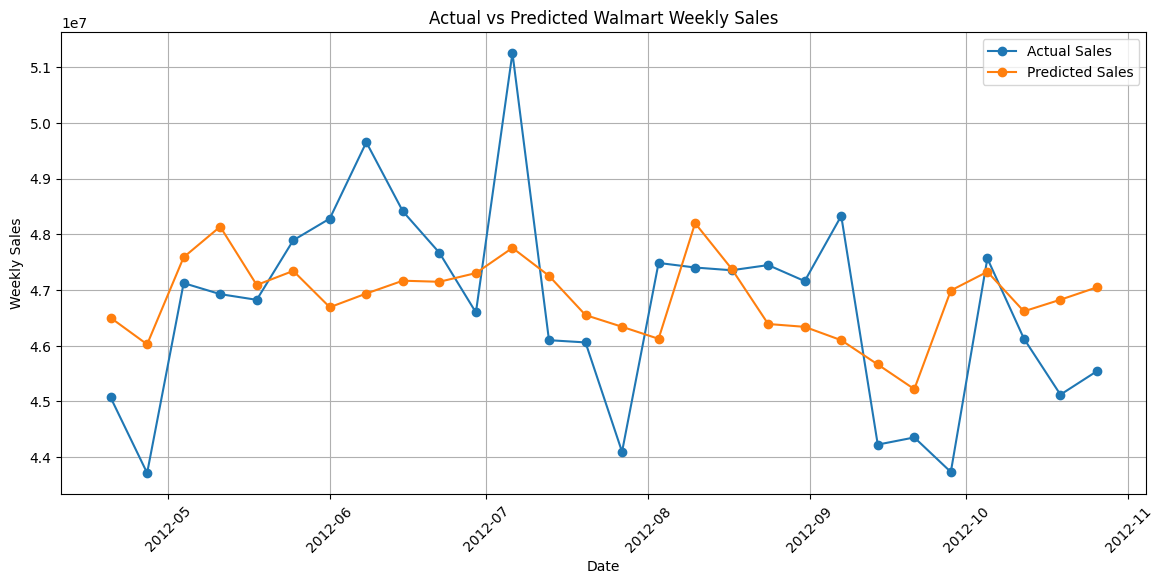

In [17]:
plt.figure(figsize=(14, 6))

plt.plot(
    results["Date"],
    results["Actual_Sales"],
    label="Actual Sales",
    marker="o"
)

plt.plot(
    results["Date"],
    results["Predicted_Sales"],
    label="Predicted Sales",
    marker="o"
)

plt.title("Actual vs Predicted Walmart Weekly Sales")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.grid(True)

plt.xticks(rotation=45)

plt.show()

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

mean_sales = y_test.mean()
mae_percentage = (mae / mean_sales) * 100

print(f"MAE: {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R² Score: {r2:.4f}")
print(f"MAE as % of Average Sales: {mae_percentage:.2f}%")

MAE: 1,292,216.63
RMSE: 1,565,506.17
R² Score: 0.2100
MAE as % of Average Sales: 2.77%


In [19]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
2,Week,0.523324
3,Lag_1,0.200144
5,Lag_4,0.157810
4,Lag_2,0.044277
6,Rolling_Mean_4,0.040123
1,Month,0.019939
0,Year,0.014382


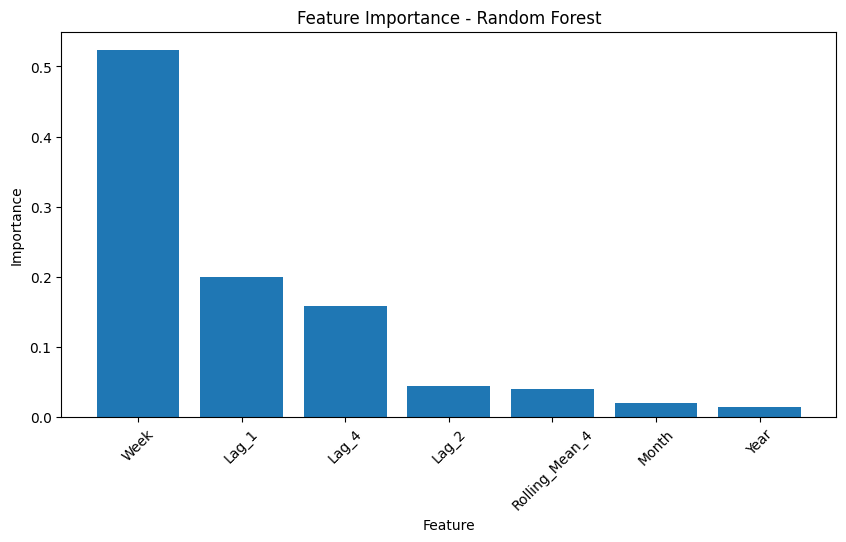

In [20]:
plt.figure(figsize=(10, 5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Feature")
plt.ylabel("Importance")

plt.xticks(rotation=45)
plt.show()

In [21]:
weekly_sales_v2 = (
    df.groupby("Date")["Weekly_Sales"]
    .sum()
    .reset_index()
    .sort_values("Date")
)

# Time features
weekly_sales_v2["Year"] = weekly_sales_v2["Date"].dt.year
weekly_sales_v2["Month"] = weekly_sales_v2["Date"].dt.month
weekly_sales_v2["Week"] = (
    weekly_sales_v2["Date"]
    .dt.isocalendar()
    .week
    .astype(int)
)

# Lag features
weekly_sales_v2["Lag_1"] = weekly_sales_v2["Weekly_Sales"].shift(1)
weekly_sales_v2["Lag_2"] = weekly_sales_v2["Weekly_Sales"].shift(2)
weekly_sales_v2["Lag_4"] = weekly_sales_v2["Weekly_Sales"].shift(4)

# Same period last year
weekly_sales_v2["Lag_52"] = weekly_sales_v2["Weekly_Sales"].shift(52)

# Rolling average - past data only
weekly_sales_v2["Rolling_Mean_4"] = (
    weekly_sales_v2["Weekly_Sales"]
    .shift(1)
    .rolling(4)
    .mean()
)

weekly_sales_v2 = weekly_sales_v2.dropna().reset_index(drop=True)

weekly_sales_v2.head()

,Date,Weekly_Sales,Year,Month,Week,Lag_1,Lag_2,Lag_4,Lag_52,Rolling_Mean_4
0,2011-02-04,46153111.12,2011,2,5,39599852.99,40654648.03,42775787.77,49750740.50,4.092599e+07
1,2011-02-11,47336192.79,2011,2,6,46153111.12,39599852.99,40673678.04,48336677.63,4.177032e+07
2,2011-02-18,48716164.12,2011,2,7,47336192.79,46153111.12,40654648.03,48276993.78,4.343595e+07
3,2011-02-25,44125859.84,2011,2,8,48716164.12,47336192.79,39599852.99,43968571.13,4.545133e+07
4,2011-03-04,46980603.74,2011,3,9,44125859.84,48716164.12,46153111.12,46871470.30,4.658283e+07


In [22]:
features_v2 = [
    "Year",
    "Month",
    "Week",
    "Lag_1",
    "Lag_2",
    "Lag_4",
    "Lag_52",
    "Rolling_Mean_4"
]

X_v2 = weekly_sales_v2[features_v2]
y_v2 = weekly_sales_v2["Weekly_Sales"]

print("Number of samples:", len(weekly_sales_v2))

Number of samples: 91


In [23]:
test_start_date = dates_test.iloc[0]

print("Test starts from:", test_start_date)

Test starts from: 2012-04-20 00:00:00


In [24]:
train_mask = weekly_sales_v2["Date"] < test_start_date
test_mask = weekly_sales_v2["Date"] >= test_start_date

X_train_v2 = X_v2[train_mask]
X_test_v2 = X_v2[test_mask]

y_train_v2 = y_v2[train_mask]
y_test_v2 = y_v2[test_mask]

dates_test_v2 = weekly_sales_v2.loc[test_mask, "Date"]

print("Training samples:", len(X_train_v2))
print("Testing samples:", len(X_test_v2))

print(
    "Test period:",
    dates_test_v2.min(),
    "to",
    dates_test_v2.max()
)

Training samples: 63
Testing samples: 28
Test period: 2012-04-20 00:00:00 to 2012-10-26 00:00:00


In [25]:
model_v2 = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model_v2.fit(X_train_v2, y_train_v2)

y_pred_v2 = model_v2.predict(X_test_v2)

In [26]:
mae_v2 = mean_absolute_error(y_test_v2, y_pred_v2)

rmse_v2 = np.sqrt(
    mean_squared_error(y_test_v2, y_pred_v2)
)

r2_v2 = r2_score(y_test_v2, y_pred_v2)

mae_percentage_v2 = (
    mae_v2 / y_test_v2.mean()
) * 100

print(f"MAE: {mae_v2:,.2f}")
print(f"RMSE: {rmse_v2:,.2f}")
print(f"R² Score: {r2_v2:.4f}")
print(f"MAE as % of Average Sales: {mae_percentage_v2:.2f}%")

MAE: 1,296,423.73
RMSE: 1,656,882.69
R² Score: 0.1151
MAE as % of Average Sales: 2.78%


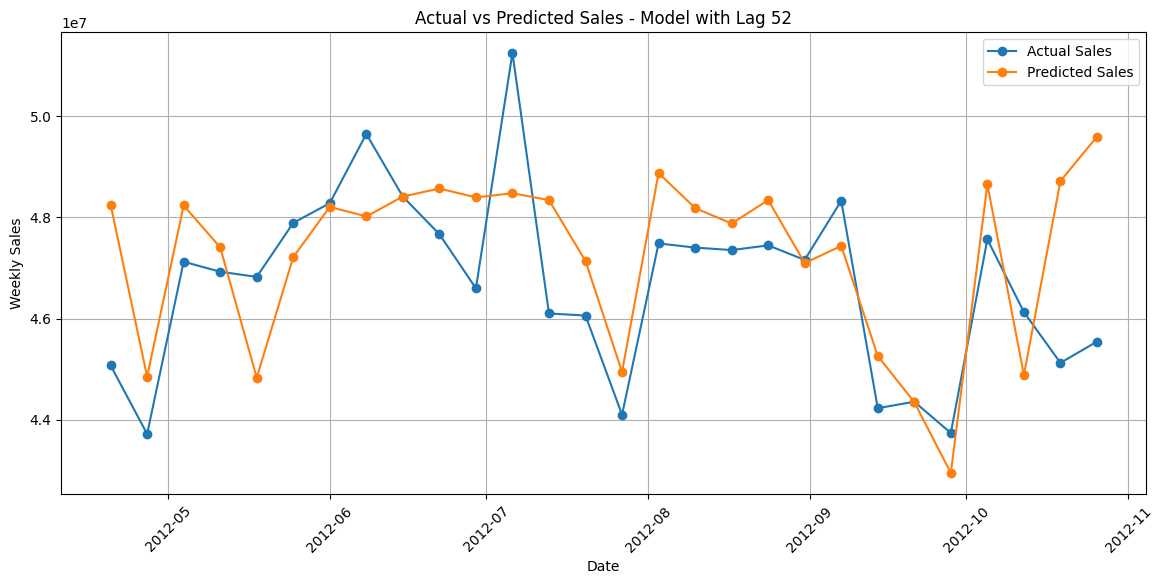

In [27]:
results_v2 = pd.DataFrame({
    "Date": dates_test_v2.values,
    "Actual_Sales": y_test_v2.values,
    "Predicted_Sales": y_pred_v2
})

plt.figure(figsize=(14, 6))

plt.plot(
    results_v2["Date"],
    results_v2["Actual_Sales"],
    label="Actual Sales",
    marker="o"
)

plt.plot(
    results_v2["Date"],
    results_v2["Predicted_Sales"],
    label="Predicted Sales",
    marker="o"
)

plt.title("Actual vs Predicted Sales - Model with Lag 52")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

plt.show()

In [28]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

for fold, (train_index, val_index) in enumerate(tscv.split(X_v2), start=1):
    print(
        f"Fold {fold}: "
        f"Train = {len(train_index)}, "
        f"Validation = {len(val_index)}"
    )

Fold 1: Train = 16, Validation = 15
Fold 2: Train = 31, Validation = 15
Fold 3: Train = 46, Validation = 15
Fold 4: Train = 61, Validation = 15
Fold 5: Train = 76, Validation = 15


In [29]:
rf_mae_scores = []

for fold, (train_index, val_index) in enumerate(tscv.split(X_v2), start=1):

    X_train_fold = X_v2.iloc[train_index]
    X_val_fold = X_v2.iloc[val_index]

    y_train_fold = y_v2.iloc[train_index]
    y_val_fold = y_v2.iloc[val_index]

    rf_model = RandomForestRegressor(
        n_estimators=200,
        random_state=42
    )

    rf_model.fit(X_train_fold, y_train_fold)

    predictions = rf_model.predict(X_val_fold)

    fold_mae = mean_absolute_error(
        y_val_fold,
        predictions
    )

    rf_mae_scores.append(fold_mae)

    print(f"Fold {fold} MAE: {fold_mae:,.2f}")

print("\nAverage Random Forest MAE:")
print(f"{np.mean(rf_mae_scores):,.2f}")

Fold 1 MAE: 1,427,761.94
Fold 2 MAE: 4,012,706.51
Fold 3 MAE: 2,879,753.14
Fold 4 MAE: 1,875,458.81
Fold 5 MAE: 931,073.96

Average Random Forest MAE:
2,225,350.87


In [30]:
from xgboost import XGBRegressor

In [31]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(
    X_train_v2,
    y_train_v2
)

y_pred_xgb = xgb_model.predict(X_test_v2)

In [32]:
mae_xgb = mean_absolute_error(
    y_test_v2,
    y_pred_xgb
)

rmse_xgb = np.sqrt(
    mean_squared_error(y_test_v2, y_pred_xgb)
)

r2_xgb = r2_score(
    y_test_v2,
    y_pred_xgb
)

mae_percentage_xgb = (
    mae_xgb / y_test_v2.mean()
) * 100

print(f"XGBoost MAE: {mae_xgb:,.2f}")
print(f"XGBoost RMSE: {rmse_xgb:,.2f}")
print(f"XGBoost R²: {r2_xgb:.4f}")
print(f"XGBoost MAE %: {mae_percentage_xgb:.2f}%")

XGBoost MAE: 1,349,804.21
XGBoost RMSE: 1,932,089.36
XGBoost R²: -0.2033
XGBoost MAE %: 2.89%


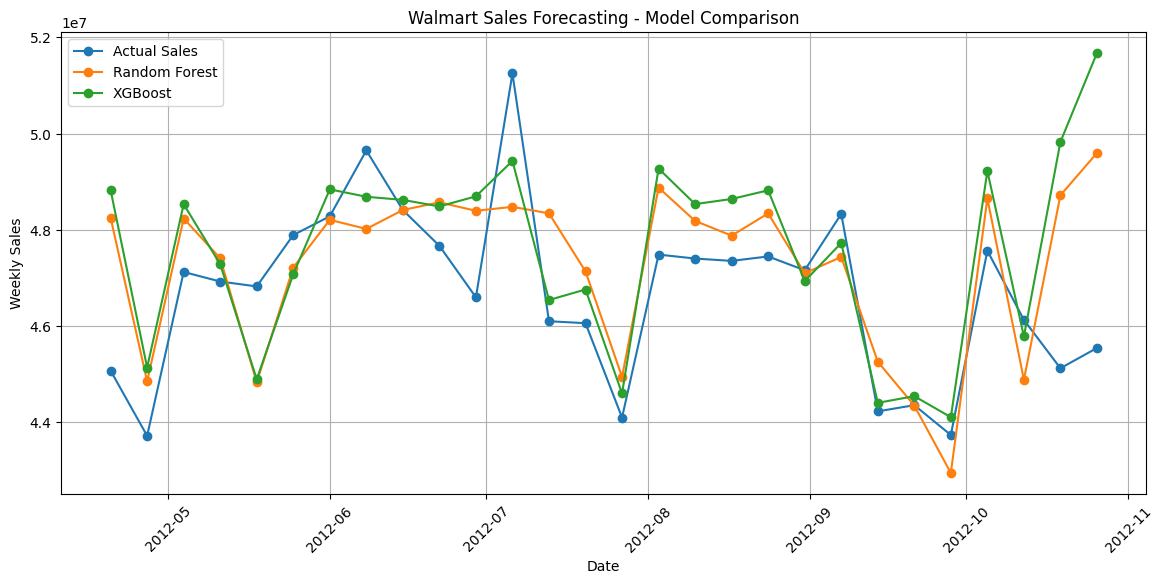

In [33]:
plt.figure(figsize=(14, 6))

plt.plot(
    dates_test_v2,
    y_test_v2,
    label="Actual Sales",
    marker="o"
)

plt.plot(
    dates_test_v2,
    y_pred_v2,
    label="Random Forest",
    marker="o"
)

plt.plot(
    dates_test_v2,
    y_pred_xgb,
    label="XGBoost",
    marker="o"
)

plt.title("Walmart Sales Forecasting - Model Comparison")

plt.xlabel("Date")
plt.ylabel("Weekly Sales")

plt.legend()
plt.grid(True)

plt.xticks(rotation=45)

plt.show()

In [34]:
xgb_mae_scores = []

for fold, (train_index, val_index) in enumerate(tscv.split(X_v2), start=1):

    X_train_fold = X_v2.iloc[train_index]
    X_val_fold = X_v2.iloc[val_index]

    y_train_fold = y_v2.iloc[train_index]
    y_val_fold = y_v2.iloc[val_index]

    xgb_fold_model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    xgb_fold_model.fit(
        X_train_fold,
        y_train_fold
    )

    predictions = xgb_fold_model.predict(
        X_val_fold
    )

    fold_mae = mean_absolute_error(
        y_val_fold,
        predictions
    )

    xgb_mae_scores.append(fold_mae)

    print(
        f"Fold {fold} MAE: "
        f"{fold_mae:,.2f}"
    )

print("\nAverage XGBoost MAE:")
print(f"{np.mean(xgb_mae_scores):,.2f}")

Fold 1 MAE: 1,639,201.15
Fold 2 MAE: 3,970,198.84
Fold 3 MAE: 2,844,769.11
Fold 4 MAE: 1,629,867.93
Fold 5 MAE: 1,092,699.87

Average XGBoost MAE:
2,235,347.38


In [35]:
mae_xgb = mean_absolute_error(y_test_v2, y_pred_xgb)

rmse_xgb = np.sqrt(
    mean_squared_error(y_test_v2, y_pred_xgb)
)

r2_xgb = r2_score(y_test_v2, y_pred_xgb)

mae_percentage_xgb = (
    mae_xgb / y_test_v2.mean()
) * 100

print(f"XGBoost MAE: {mae_xgb:,.2f}")
print(f"XGBoost RMSE: {rmse_xgb:,.2f}")
print(f"XGBoost R²: {r2_xgb:.4f}")
print(f"XGBoost MAE %: {mae_percentage_xgb:.2f}%")

XGBoost MAE: 1,349,804.21
XGBoost RMSE: 1,932,089.36
XGBoost R²: -0.2033
XGBoost MAE %: 2.89%


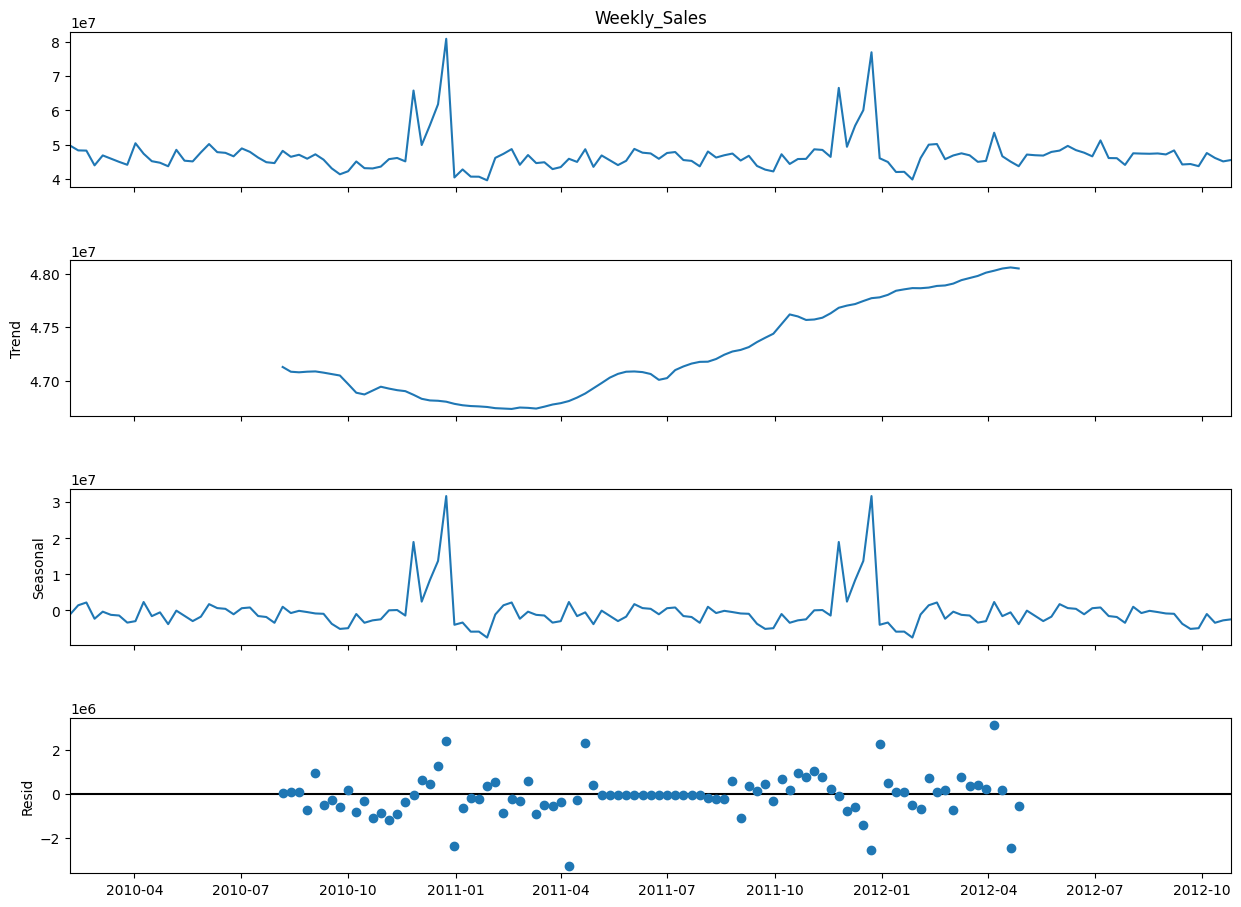

In [36]:
from statsmodels.tsa.seasonal import seasonal_decompose

sales_series = (
    df.groupby("Date")["Weekly_Sales"]
    .sum()
    .sort_index()
)

decomposition = seasonal_decompose(
    sales_series,
    model="additive",
    period=52
)

fig = decomposition.plot()
fig.set_size_inches(14, 10)

plt.show()
